In [42]:
# %pip install torchvision
# %pip install matplotlib

from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
import torch

In [43]:
def create_canvas(image_size):
    return torch.zeros(1,image_size, image_size)

In [44]:
import random

def merge_image_canvas(image, canvas, IMAGE_SIZE, DIGIT_SIZE):
    x_max = IMAGE_SIZE - DIGIT_SIZE
    y_max = IMAGE_SIZE - DIGIT_SIZE

    x0 = random.randint(0, x_max)
    y0 = random.randint(0, y_max)

    canvas[:, x0:x0+DIGIT_SIZE, y0:y0+DIGIT_SIZE] = image

    return canvas, x0, y0

def object_center(x0, y0, DIGIT_SIZE, IMAGE_SIZE):
    x_center = ((x0 + DIGIT_SIZE)/2)/IMAGE_SIZE
    y_center = ((y0 + DIGIT_SIZE)/2)/IMAGE_SIZE
    height = DIGIT_SIZE / IMAGE_SIZE

    return x_center, y_center, height, height


In [45]:
def assign_cell(x_center, y_center, S):
    x_cell = int(x_center * S)
    y_cell = int(y_center * S)

    #Edge case of when x_center = 1, as x_cell becomes (1 * S), but S is out of bound
    x_cell = min(x_cell, S - 1)
    y_cell = min(y_cell, S - 1)

    return x_cell, y_cell

In [46]:
def relative_positions(x_center, y_center, x_cell, y_cell, S):
    x_rel = x_center * S - x_cell
    y_rel = y_center * S - y_cell

    return x_rel, y_rel

In [47]:
def build_target(x_center, y_center, b_height, b_width, S):
    x_cell, y_cell = assign_cell(x_center, y_center, S)
    x_rel, y_rel = relative_positions(x_center, y_center, x_cell, y_cell, S)

    target = torch.zeros(S, S, 5)

    target[x_cell][y_cell][0] = 1
    target[x_cell][y_cell][1] = x_rel
    target[x_cell][y_cell][2] = y_rel
    target[x_cell][y_cell][3] = b_height
    target[x_cell][y_cell][4] = b_width

    return target

In [48]:
from torch.utils.data import Dataset

IMAGE_SIZE = 64
DIGIT_SIZE = 28
S = 8

class ImageDataset(Dataset):

    def __init__(self, nine_digit):
        self.images = nine_digit
        self.length = len(nine_digit)

    def __len__(self):
        return self.length
    
    def __getitem__(self, index):

        image = self.images[index]
        canvas = create_canvas(IMAGE_SIZE)
        image_in_canvas, x0, y0 = merge_image_canvas(image, canvas, IMAGE_SIZE, DIGIT_SIZE)
        x_center, y_center, b_height, b_width = object_center(x0, y0, DIGIT_SIZE, IMAGE_SIZE)
        target = build_target(x_center, y_center, b_height, b_width, S)
        return image_in_canvas, target


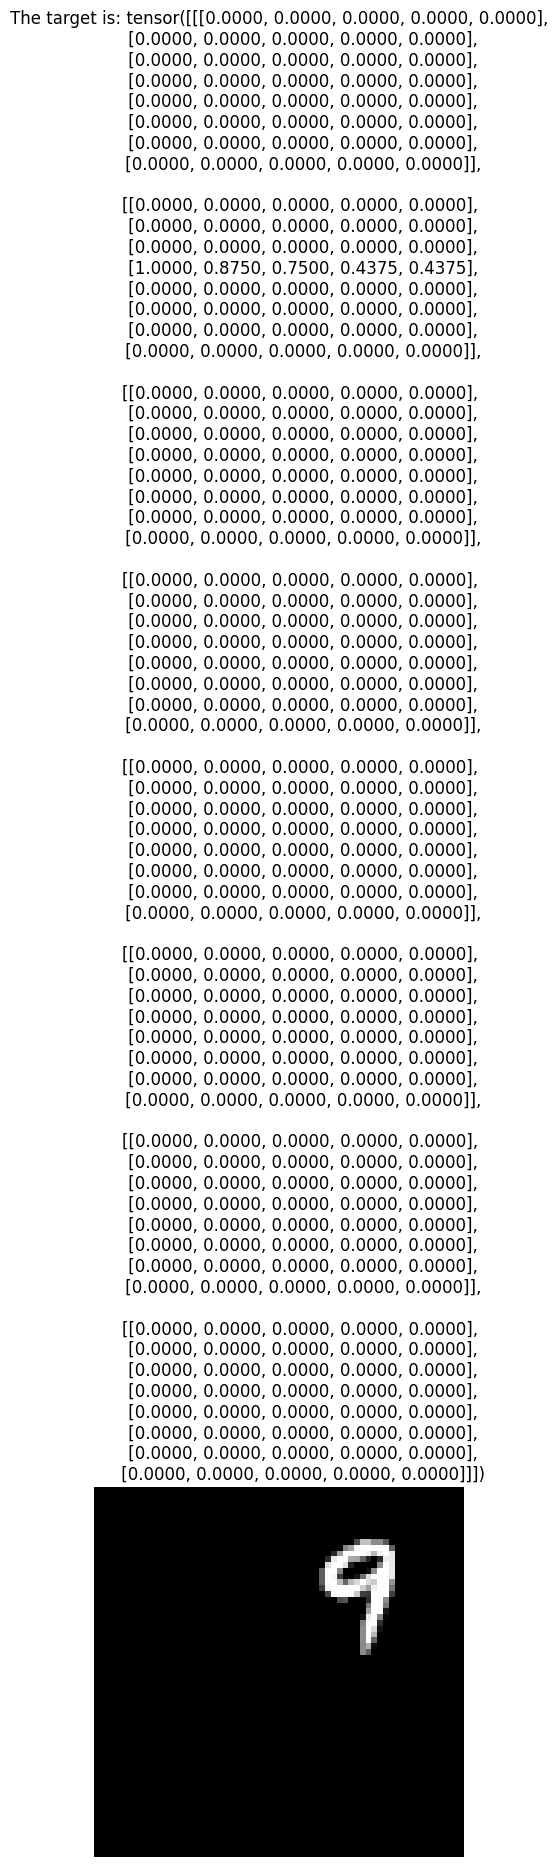

In [52]:
mnist = MNIST(
            root="./data",
            train=True,
            download=True,
            transform=transforms.ToTensor()
        )

nine_digits = [img for img, label in mnist if label==9]

custom_dataset = ImageDataset(nine_digits)
img, target = custom_dataset[12]
# print(img)

plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"The target is: {target}")
plt.axis("off")
plt.show()